# トークン数分布調査ノートブック

各SFTデータセット・DPOデータセットのトークン数分布を計測し、適切な `MAX_SEQ_LEN` を決定するためのノートブックです。

**GPUは不要（CPU実行で十分）**

In [1]:
# 依存関係のインストール
!pip install -q transformers datasets pandas matplotlib

In [2]:
from transformers import AutoTokenizer
from datasets import load_dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from collections import defaultdict

# ============================================================
# Qwen3-4B-Instruct のトークナイザーを読み込み
# ============================================================
MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Tokenizer loaded: Qwen/Qwen3-4B-Instruct-2507
Vocab size: 151643


In [3]:
# ============================================================
# 調査対象データセット一覧
# ============================================================

SFT_DATASETS = {
    "1-1_512_v2": "u-10bei/structured_data_with_cot_dataset_512_v2",
    "1-2_512_v4": "u-10bei/structured_data_with_cot_dataset_512_v4",
    "1-3_512_v5": "u-10bei/structured_data_with_cot_dataset_512_v5",
    "1-4_512": "u-10bei/structured_data_with_cot_dataset_512",
    "1-5_v2": "u-10bei/structured_data_with_cot_dataset_v2",
    "1-6_base": "u-10bei/structured_data_with_cot_dataset",
    "2-1_3k_mix": "daichira/structured-3k-mix-sft",
    "2-2_5k_mix": "daichira/structured-5k-mix-sft",
    "2-3_hard_4k": "daichira/structured-hard-sft-4k",
}

DPO_DATASETS = {
    "dpo_qwen_cot": "u-10bei/dpo-dataset-qwen-cot",
}

print(f"SFTデータセット: {len(SFT_DATASETS)}個")
print(f"DPOデータセット: {len(DPO_DATASETS)}個")

SFTデータセット: 9個
DPOデータセット: 1個


In [4]:
# ============================================================
# SFTデータセットのトークン数計測関数
# ============================================================

def analyze_sft_dataset(dataset_id, tokenizer, max_samples=None):
    """
    SFTデータセット（messages形式）のトークン数分布を計測する。

    Returns:
        dict: 統計情報
        list: 各サンプルのトークン数リスト
    """
    print(f"\n{'='*60}")
    print(f"Loading: {dataset_id}")
    print(f"{'='*60}")

    ds = load_dataset(dataset_id, split="train")
    print(f"Total samples: {len(ds)}")

    if max_samples and len(ds) > max_samples:
        ds = ds.select(range(max_samples))
        print(f"Truncated to: {max_samples} samples")

    # カラム名を確認
    print(f"Columns: {ds.column_names}")

    # messagesカラムの有無を確認
    if "messages" not in ds.column_names:
        print(f"WARNING: 'messages' column not found. Available: {ds.column_names}")
        # 最初のサンプルを表示して構造を確認
        print(f"First sample keys: {list(ds[0].keys())}")
        return None, None

    token_lengths = []
    user_lengths = []
    assistant_lengths = []

    for i, row in enumerate(ds):
        messages = row["messages"]

        # 全体のトークン数（chat_template適用後）
        full_text = tokenizer.apply_chat_template(messages, tokenize=False)
        full_tokens = tokenizer(full_text, return_length=True)
        total_len = full_tokens["length"][0]
        token_lengths.append(total_len)

        # role別のトークン数
        for msg in messages:
            msg_tokens = tokenizer(msg["content"], return_length=True)["length"][0]
            if msg["role"] == "user":
                user_lengths.append(msg_tokens)
            elif msg["role"] == "assistant":
                assistant_lengths.append(msg_tokens)

    token_lengths = np.array(token_lengths)

    stats = {
        "dataset": dataset_id,
        "num_samples": len(token_lengths),
        "min": int(np.min(token_lengths)),
        "max": int(np.max(token_lengths)),
        "mean": float(np.mean(token_lengths)),
        "median": float(np.median(token_lengths)),
        "p75": float(np.percentile(token_lengths, 75)),
        "p90": float(np.percentile(token_lengths, 90)),
        "p95": float(np.percentile(token_lengths, 95)),
        "p99": float(np.percentile(token_lengths, 99)),
        "over_512": int(np.sum(token_lengths > 512)),
        "over_512_pct": float(np.mean(token_lengths > 512) * 100),
        "over_1024": int(np.sum(token_lengths > 1024)),
        "over_1024_pct": float(np.mean(token_lengths > 1024) * 100),
        "over_2048": int(np.sum(token_lengths > 2048)),
        "over_2048_pct": float(np.mean(token_lengths > 2048) * 100),
    }

    print(f"\n--- Statistics ---")
    print(f"  Samples:  {stats['num_samples']}")
    print(f"  Min:      {stats['min']}")
    print(f"  Max:      {stats['max']}")
    print(f"  Mean:     {stats['mean']:.0f}")
    print(f"  Median:   {stats['median']:.0f}")
    print(f"  P75:      {stats['p75']:.0f}")
    print(f"  P90:      {stats['p90']:.0f}")
    print(f"  P95:      {stats['p95']:.0f}")
    print(f"  P99:      {stats['p99']:.0f}")
    print(f"  >512:     {stats['over_512']} ({stats['over_512_pct']:.1f}%)")
    print(f"  >1024:    {stats['over_1024']} ({stats['over_1024_pct']:.1f}%)")
    print(f"  >2048:    {stats['over_2048']} ({stats['over_2048_pct']:.1f}%)")

    return stats, token_lengths

In [5]:
# ============================================================
# DPOデータセットのトークン数計測関数
# ============================================================

def analyze_dpo_dataset(dataset_id, tokenizer, max_samples=None):
    """
    DPOデータセット（chosen/rejected形式）のトークン数分布を計測する。
    """
    print(f"\n{'='*60}")
    print(f"Loading DPO: {dataset_id}")
    print(f"{'='*60}")

    ds = load_dataset(dataset_id, split="train")
    print(f"Total samples: {len(ds)}")
    print(f"Columns: {ds.column_names}")

    if max_samples and len(ds) > max_samples:
        ds = ds.select(range(max_samples))

    # 最初のサンプルの構造を表示
    first = ds[0]
    print(f"\nFirst sample structure:")
    for k, v in first.items():
        if isinstance(v, str):
            print(f"  {k}: (str, len={len(v)}) '{v[:100]}...'")
        elif isinstance(v, list):
            print(f"  {k}: (list, len={len(v)})")
            if len(v) > 0 and isinstance(v[0], dict):
                for item in v[:2]:
                    print(f"    - {item}")
        else:
            print(f"  {k}: {type(v).__name__} = {v}")

    # chosen/rejected のトークン数を計測
    chosen_lengths = []
    rejected_lengths = []

    for row in ds:
        # chosen
        if "chosen" in row:
            chosen = row["chosen"]
            if isinstance(chosen, list):  # messages形式
                text = tokenizer.apply_chat_template(chosen, tokenize=False)
            else:  # テキスト形式
                text = chosen
            chosen_lengths.append(tokenizer(text, return_length=True)["length"][0])

        # rejected
        if "rejected" in row:
            rejected = row["rejected"]
            if isinstance(rejected, list):  # messages形式
                text = tokenizer.apply_chat_template(rejected, tokenize=False)
            else:  # テキスト形式
                text = rejected
            rejected_lengths.append(tokenizer(text, return_length=True)["length"][0])

    for name, lengths in [("chosen", chosen_lengths), ("rejected", rejected_lengths)]:
        if lengths:
            arr = np.array(lengths)
            print(f"\n--- {name} ---")
            print(f"  Min: {np.min(arr)}, Max: {np.max(arr)}")
            print(f"  Mean: {np.mean(arr):.0f}, Median: {np.median(arr):.0f}")
            print(f"  P95: {np.percentile(arr, 95):.0f}, P99: {np.percentile(arr, 99):.0f}")
            print(f"  >512: {np.sum(arr > 512)} ({np.mean(arr > 512)*100:.1f}%)")
            print(f"  >1024: {np.sum(arr > 1024)} ({np.mean(arr > 1024)*100:.1f}%)")
            print(f"  >2048: {np.sum(arr > 2048)} ({np.mean(arr > 2048)*100:.1f}%)")

    return {"chosen": chosen_lengths, "rejected": rejected_lengths}

In [6]:
# ============================================================
# 全SFTデータセットを一括調査
# ============================================================

all_stats = []
all_lengths = {}

for short_name, dataset_id in SFT_DATASETS.items():
    try:
        stats, lengths = analyze_sft_dataset(dataset_id, tokenizer)
        if stats:
            stats["short_name"] = short_name
            all_stats.append(stats)
            all_lengths[short_name] = lengths
    except Exception as e:
        print(f"ERROR loading {dataset_id}: {e}")

print(f"\n\n{'='*60}")
print(f"完了: {len(all_stats)}/{len(SFT_DATASETS)} データセットを計測")
print(f"{'='*60}")


Loading: u-10bei/structured_data_with_cot_dataset_512_v2


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3933 [00:00<?, ? examples/s]

Total samples: 3933
Columns: ['messages', 'metadata']

--- Statistics ---
  Samples:  3933
  Min:      136
  Max:      1243
  Mean:     405
  Median:   361
  P75:      510
  P90:      639
  P95:      743
  P99:      961
  >512:     967 (24.6%)
  >1024:    25 (0.6%)
  >2048:    0 (0.0%)

Loading: u-10bei/structured_data_with_cot_dataset_512_v4


...

Total samples: 5000
Columns: ['id', 'category', 'subcategory', 'task', 'seed', 'messages']

--- Statistics ---
  Samples:  5000
  Min:      118
  Max:      2503
  Mean:     991
  Median:   1036
  P75:      1600
  P90:      1958
  P95:      2113
  P99:      2295
  >512:     2875 (57.5%)
  >1024:    2535 (50.7%)
  >2048:    337 (6.7%)

Loading: daichira/structured-hard-sft-4k


README.md: 0.00B [00:00, ?B/s]

synthetic_hard_structured_v1.jsonl:   0%|          | 0.00/11.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4000 [00:00<?, ? examples/s]

Total samples: 4000
Columns: ['id', 'category', 'subcategory', 'task', 'seed', 'messages']

--- Statistics ---
  Samples:  4000
  Min:      198
  Max:      2489
  Mean:     954
  Median:   560
  P75:      1637
  P90:      2045
  P95:      2199
  P99:      2360
  >512:     2000 (50.0%)
  >1024:    1913 (47.8%)
  >2048:    398 (10.0%)


完了: 9/9 データセットを計測


In [7]:
# ============================================================
# DPOデータセットの調査
# ============================================================

for short_name, dataset_id in DPO_DATASETS.items():
    try:
        dpo_result = analyze_dpo_dataset(dataset_id, tokenizer)
    except Exception as e:
        print(f"ERROR loading {dataset_id}: {e}")


Loading DPO: u-10bei/dpo-dataset-qwen-cot


README.md:   0%|          | 0.00/387 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.37M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4040 [00:00<?, ? examples/s]

Total samples: 4040
Columns: ['prompt', 'chosen', 'rejected', 'strategy']

First sample structure:
  prompt: (str, len=254) '<|im_start|>system
You are a helpful assistant. Please format your response as follows:
Approach: <s...'
  chosen: (str, len=737) 'Approach:
1. Task: Create api specification in TOML
2. Complexity: complex - 8-10 fields, 3-4 levels...'
  rejected: (str, len=2450) 'Approach:  
1. Understand the purpose of a TOML document for an API specification. TOML (Tom's Obvio...'
  strategy: (str, len=15) 'model_generated...'

--- chosen ---
  Min: 87, Max: 884
  Mean: 275, Median: 254
  P95: 504, P99: 626
  >512: 190 (4.7%)
  >1024: 0 (0.0%)
  >2048: 0 (0.0%)

--- rejected ---
  Min: 104, Max: 1027
  Mean: 475, Median: 418
  P95: 1019, P99: 1024
  >512: 1275 (31.6%)
  >1024: 3 (0.1%)
  >2048: 0 (0.0%)


In [8]:
# ============================================================
# 結果をDataFrameで一覧表示
# ============================================================

if all_stats:
    df = pd.DataFrame(all_stats)
    display_cols = [
        "short_name", "num_samples", "min", "max", "mean", "median",
        "p90", "p95", "p99",
        "over_512", "over_512_pct", "over_1024", "over_1024_pct", "over_2048", "over_2048_pct"
    ]
    df_display = df[display_cols].copy()

    # 数値フォーマット
    for col in ["mean", "median", "p90", "p95", "p99"]:
        df_display[col] = df_display[col].round(0).astype(int)
    for col in ["over_512_pct", "over_1024_pct", "over_2048_pct"]:
        df_display[col] = df_display[col].round(1)

    print("\n" + "="*80)
    print("全SFTデータセットのトークン数統計一覧")
    print("="*80)
    print(df_display.to_string(index=False))

    # MAX_SEQ_LEN推奨値の算出
    print("\n" + "="*80)
    print("MAX_SEQ_LEN 推奨値（各データセット）")
    print("="*80)
    for _, row in df.iterrows():
        p95 = int(row["p95"])
        p99 = int(row["p99"])
        max_val = int(row["max"])
        # 推奨: P95をカバーし、2の冪に切り上げ
        recommended = 1
        while recommended < p95:
            recommended *= 2
        print(f"  {row['short_name']:20s}: P95={p95:5d}, P99={p99:5d}, Max={max_val:5d} → 推奨 MAX_SEQ_LEN = {recommended}")


全SFTデータセットのトークン数統計一覧
 short_name  num_samples  min  max  mean  median  p90  p95  p99  over_512  over_512_pct  over_1024  over_1024_pct  over_2048  over_2048_pct
 1-1_512_v2         3933  136 1243   405     361  639  743  961       967          24.6         25            0.6          0            0.0
 1-2_512_v4         4608  175 1115   346     283  614  689  797       814          17.7          4            0.1          0            0.0
 1-3_512_v5         4547  165 1716   351     291  617  700  986       807          17.7         34            0.7          0            0.0
    1-4_512         3445  138 1097   379     335  592  679  911       633          18.4         11            0.3          0            0.0
     1-5_v2         2500  137  923   339     307  521  600  752       281          11.2          0            0.0          0            0.0
   1-6_base         2500  120  757   302     279  467  537  640       153           6.1          0            0.0          0            0.

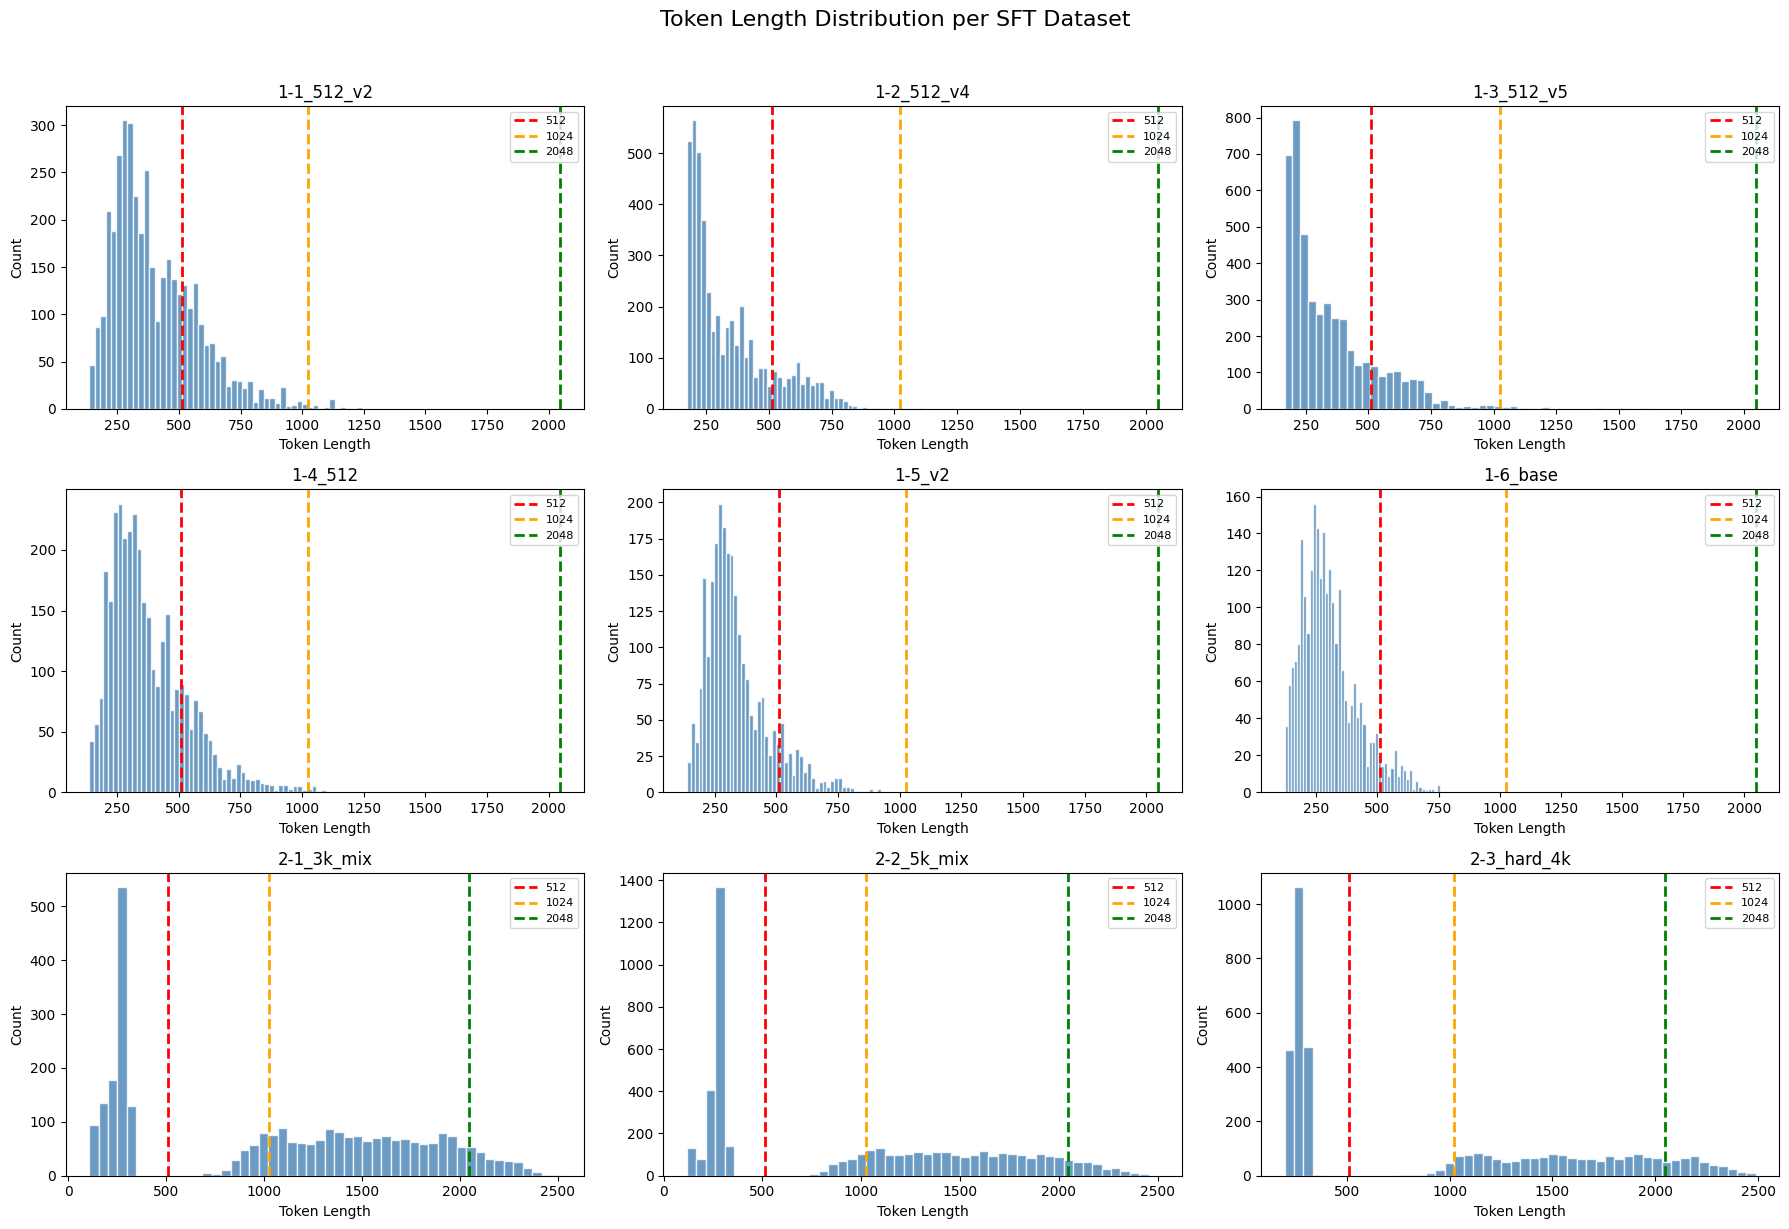


図を token_length_distribution.png に保存しました。


In [9]:
# ============================================================
# ヒストグラムで可視化
# ============================================================

if all_lengths:
    n_datasets = len(all_lengths)
    fig, axes = plt.subplots(
        (n_datasets + 2) // 3, 3,
        figsize=(18, 4 * ((n_datasets + 2) // 3))
    )
    axes = axes.flatten()

    for idx, (name, lengths) in enumerate(all_lengths.items()):
        ax = axes[idx]
        ax.hist(lengths, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
        ax.axvline(x=512, color="red", linestyle="--", linewidth=2, label="512")
        ax.axvline(x=1024, color="orange", linestyle="--", linewidth=2, label="1024")
        ax.axvline(x=2048, color="green", linestyle="--", linewidth=2, label="2048")
        ax.set_title(name, fontsize=12)
        ax.set_xlabel("Token Length")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)

    # 余ったサブプロットを非表示
    for idx in range(len(all_lengths), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle("Token Length Distribution per SFT Dataset", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig("token_length_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n図を token_length_distribution.png に保存しました。")

In [10]:
# ============================================================
# 512トークンでどれだけ情報が失われるかの分析
# （現在のデフォルト設定での損失量を可視化）
# ============================================================

if all_lengths:
    print("\n" + "="*80)
    print("MAX_SEQ_LEN=512 での情報損失分析")
    print("="*80)

    for name, lengths in all_lengths.items():
        arr = np.array(lengths)
        over_512 = arr[arr > 512]
        if len(over_512) > 0:
            # 512を超えた分のトークン数合計（切り詰められたトークン数）
            truncated_tokens = np.sum(over_512 - 512)
            total_tokens = np.sum(arr)
            loss_pct = truncated_tokens / total_tokens * 100

            print(f"\n  {name}:")
            print(f"    512超のサンプル: {len(over_512)}/{len(arr)} ({len(over_512)/len(arr)*100:.1f}%)")
            print(f"    切り詰められたトークン数: {truncated_tokens:,} / {total_tokens:,} ({loss_pct:.1f}%)")
            print(f"    512超サンプルの平均超過: {np.mean(over_512 - 512):.0f} tokens")
        else:
            print(f"\n  {name}: 全サンプルが512以下 ✓")


MAX_SEQ_LEN=512 での情報損失分析

  1-1_512_v2:
    512超のサンプル: 967/3933 (24.6%)
    切り詰められたトークン数: 135,935 / 1,592,331 (8.5%)
    512超サンプルの平均超過: 141 tokens

  1-2_512_v4:
    512超のサンプル: 814/4608 (17.7%)
    切り詰められたトークン数: 108,137 / 1,593,139 (6.8%)
    512超サンプルの平均超過: 133 tokens

  1-3_512_v5:
    512超のサンプル: 807/4547 (17.7%)
    切り詰められたトークン数: 129,923 / 1,596,794 (8.1%)
    512超サンプルの平均超過: 161 tokens

  1-4_512:
    512超のサンプル: 633/3445 (18.4%)
    切り詰められたトークン数: 83,129 / 1,304,639 (6.4%)
    512超サンプルの平均超過: 131 tokens

  1-5_v2:
    512超のサンプル: 281/2500 (11.2%)
    切り詰められたトークン数: 28,004 / 846,956 (3.3%)
    512超サンプルの平均超過: 100 tokens

  1-6_base:
    512超のサンプル: 153/2500 (6.1%)
    切り詰められたトークン数: 12,126 / 753,897 (1.6%)
    512超サンプルの平均超過: 79 tokens

  2-1_3k_mix:
    512超のサンプル: 1930/3000 (64.3%)
    切り詰められたトークン数: 1,957,206 / 3,213,377 (60.9%)
    512超サンプルの平均超過: 1014 tokens

  2-2_5k_mix:
    512超のサンプル: 2875/5000 (57.5%)
    切り詰められたトークン数: 2,912,387 / 4,953,157 (58.8%)
    512超サンプルの平均超過: 1013 tokens

  2-3

In [11]:
# ============================================================
# GPU別の推奨 MAX_SEQ_LEN / バッチサイズ早見表
# （Qwen3-4B + QLoRA 4bit の目安）
# ============================================================

print("\n" + "="*80)
print("GPU別の推奨設定（Qwen3-4B + QLoRA 4bit）")
print("="*80)
print("""
┌──────────┬──────────┬─────────────────┬──────────┬───────────┐
│ GPU      │ VRAM     │ MAX_SEQ_LEN     │ Batch    │ Grad Acc  │
├──────────┼──────────┼─────────────────┼──────────┼───────────┤
│ T4       │ 16 GB    │  512 ~ 1024     │ 1 ~ 2    │ 8 ~ 16    │
│ L4       │ 24 GB    │ 1024 ~ 2048     │ 2 ~ 4    │ 4 ~ 8     │
│ A100 40G │ 40 GB    │ 2048 ~ 4096     │ 4 ~ 8    │ 2 ~ 4     │
│ A100 80G │ 80 GB    │ 2048 ~ 8192     │ 8 ~ 16   │ 1 ~ 2     │
│ H100     │ 80 GB    │ 2048 ~ 8192     │ 8 ~ 16   │ 1 ~ 2     │
└──────────┴──────────┴─────────────────┴──────────┴───────────┘

※ 上記は目安です。実際のメモリ使用量はデータセット内容やLoRA設定に依存します。
※ 実効バッチサイズ = PER_DEVICE_TRAIN_BS × GRAD_ACCUM
※ 標準コードのデフォルトは実効BS = 2 × 8 = 16
""")

print("\n結果を踏まえて、v1ノートブックのハイパーパラメータを決定してください。")


GPU別の推奨設定（Qwen3-4B + QLoRA 4bit）

┌──────────┬──────────┬─────────────────┬──────────┬───────────┐
│ GPU      │ VRAM     │ MAX_SEQ_LEN     │ Batch    │ Grad Acc  │
├──────────┼──────────┼─────────────────┼──────────┼───────────┤
│ T4       │ 16 GB    │  512 ~ 1024     │ 1 ~ 2    │ 8 ~ 16    │
│ L4       │ 24 GB    │ 1024 ~ 2048     │ 2 ~ 4    │ 4 ~ 8     │
│ A100 40G │ 40 GB    │ 2048 ~ 4096     │ 4 ~ 8    │ 2 ~ 4     │
│ A100 80G │ 80 GB    │ 2048 ~ 8192     │ 8 ~ 16   │ 1 ~ 2     │
│ H100     │ 80 GB    │ 2048 ~ 8192     │ 8 ~ 16   │ 1 ~ 2     │
└──────────┴──────────┴─────────────────┴──────────┴───────────┘

※ 上記は目安です。実際のメモリ使用量はデータセット内容やLoRA設定に依存します。
※ 実効バッチサイズ = PER_DEVICE_TRAIN_BS × GRAD_ACCUM
※ 標準コードのデフォルトは実効BS = 2 × 8 = 16


結果を踏まえて、v1ノートブックのハイパーパラメータを決定してください。
